# Step 5.3 — Visualization

**Goal:** Colour-code the t-SNE projections from Step 4.1 with cluster labels and official
Hauptgruppen to visually assess clustering quality and correspondence with the official
SGBS classification.

**Why here and not in Step 4?**  
t-SNE projections without labels show the geometric structure of the data but are hard to
interpret. Cluster labels (from Steps 5.1 and 5.2) make the plots meaningful.

**Output:** one combined 2x3 report figure (rows: TF-IDF / Word2Vec;
cols: K-Means k=9 / DBSCAN / Official Hauptgruppen) and a DBSCAN noise-rate bar chart.

## 1. Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

TSNE_TFIDF_PATH    = "../data/processed/tsne_tfidf_2d.npy"
TSNE_W2V_PATH      = "../data/processed/tsne_w2v_2d.npy"
DBSCAN_TFIDF_PATH  = "../data/processed/dbscan_labels_tfidf.npy"
DBSCAN_W2V_PATH    = "../data/processed/dbscan_labels_w2v.npy"
KM_TFIDF_9_PATH    = "../data/processed/kmeans_labels_tfidf_k9.npy"
KM_W2V_9_PATH      = "../data/processed/kmeans_labels_w2v_k9.npy"
OUTLIER_FLAGS_PATH = "../data/processed/outlier_flags.csv"
CLEAN_DATA_PATH    = "../data/processed/sgbs_clean.csv"

os.makedirs("../report/figures", exist_ok=True)

# t-SNE projections
X_tfidf_tsne = np.load(TSNE_TFIDF_PATH)
X_w2v_tsne   = np.load(TSNE_W2V_PATH)

# Cluster labels
km_tfidf_9   = np.load(KM_TFIDF_9_PATH)
km_w2v_9     = np.load(KM_W2V_9_PATH)
dbscan_tfidf = np.load(DBSCAN_TFIDF_PATH)
dbscan_w2v   = np.load(DBSCAN_W2V_PATH)

# Official Hauptgruppen labels
df_full = pd.read_csv(CLEAN_DATA_PATH)
flags   = pd.read_csv(OUTLIER_FLAGS_PATH)
EXCLUDE = flags.index[flags['exclude'] == True].tolist()
df      = df_full.drop(index=EXCLUDE).reset_index(drop=True)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0].apply(
    lambda x: x if x in HAUPTGRUPPEN else 'S'
)
hg_labels = df['hauptgruppe'].tolist()

print(f"Corpus: {len(df)} documents")
print(f"t-SNE shapes: TF-IDF {X_tfidf_tsne.shape}, Word2Vec {X_w2v_tsne.shape}")

Corpus: 730 documents
t-SNE shapes: TF-IDF (730, 2), Word2Vec (730, 2)


## 2. Colour Palette and Plot Helper

In [12]:
# 9 distinct colours for K-Means k=9 and Hauptgruppen
HG_COLORS = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#fabed4'
]

def scatter_tsne(ax, X2d, labels, colors, title, label_map=None, noise_label=-1):
    """Scatter plot of a 2D t-SNE projection, coloured by cluster label."""
    for i, lbl in enumerate(sorted(set(labels))):
        mask  = np.array(labels) == lbl
        color = '#cccccc' if lbl == noise_label else colors[i % len(colors)]
        alpha = 0.35     if lbl == noise_label else 0.75
        size  = 6        if lbl == noise_label else 12
        name  = 'Noise'  if lbl == noise_label else (
            label_map.get(str(lbl), str(lbl)) if label_map else str(lbl)
        )
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   s=size, alpha=alpha, color=color, label=name, linewidths=0)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=5.5, markerscale=1.2, loc='best',
              framealpha=0.7, ncol=2 if len(set(labels)) > 6 else 1)

print("Helper function ready.")

Helper function ready.


## 3. Combined 2x3 Overview (Report Figure)

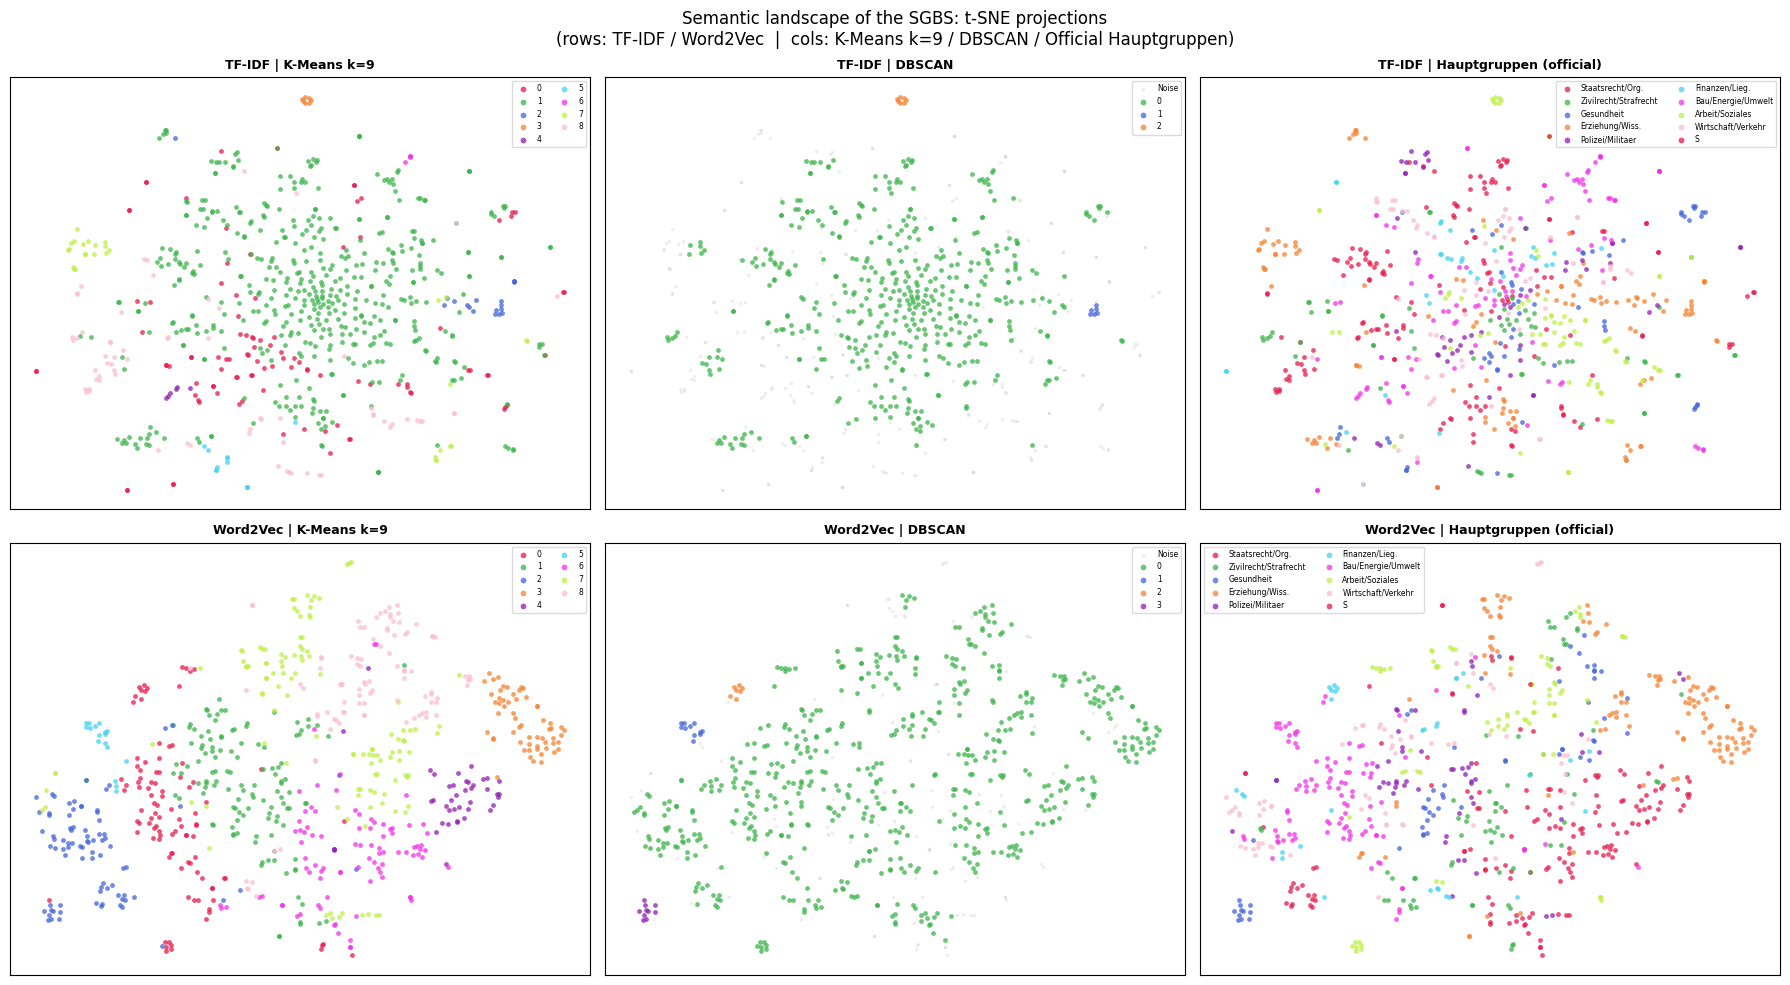

Figure saved: 05_3_tsne_overview.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

configs = [
    # (row, col, X2d,          labels,              title,                               label_map)
    (0, 0, X_tfidf_tsne, km_tfidf_9.tolist(),   "TF-IDF | K-Means k=9",             None),
    (0, 1, X_tfidf_tsne, dbscan_tfidf.tolist(), "TF-IDF | DBSCAN",                  None),
    (0, 2, X_tfidf_tsne, hg_labels,             "TF-IDF | Hauptgruppen (official)",  HAUPTGRUPPEN),
    (1, 0, X_w2v_tsne,   km_w2v_9.tolist(),     "Word2Vec | K-Means k=9",            None),
    (1, 1, X_w2v_tsne,   dbscan_w2v.tolist(),   "Word2Vec | DBSCAN",                 None),
    (1, 2, X_w2v_tsne,   hg_labels,             "Word2Vec | Hauptgruppen (official)", HAUPTGRUPPEN),
]

for row, col, X2d, labels, title, label_map in configs:
    scatter_tsne(axes[row, col], X2d, labels, HG_COLORS, title, label_map=label_map)

plt.suptitle(
    "Semantic landscape of the SGBS: t-SNE projections\n"
    "(rows: TF-IDF / Word2Vec  |  cols: K-Means k=9 / DBSCAN / Official Hauptgruppen)",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../report/figures/05_3_tsne_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 05_3_tsne_overview.png")

## 4. DBSCAN Noise Rate by Hauptgruppe

The DBSCAN noise rate is a data-driven measure of semantic homogeneity:
a high noise rate means the Hauptgruppe has no dense core in the TF-IDF space.

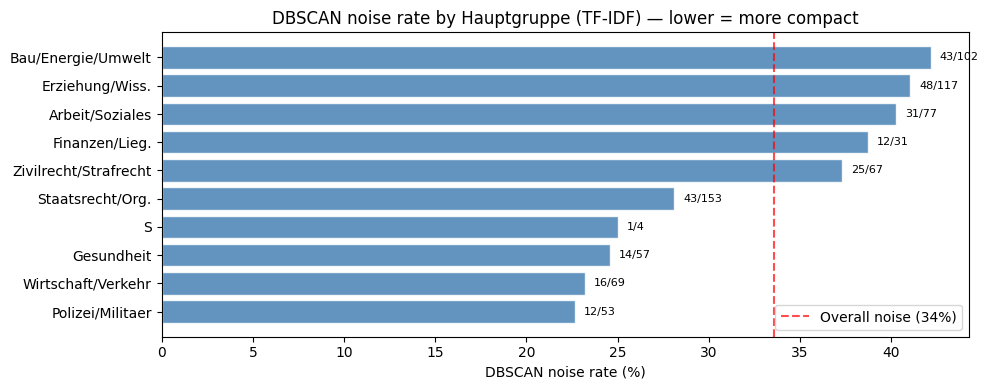

                             label  sum  count  noise_pct
hauptgruppe                                              
5                 Polizei/Militaer   12     53  22.641509
9               Wirtschaft/Verkehr   16     69  23.188406
3                       Gesundheit   14     57  24.561404
S                                S    1      4  25.000000
1                 Staatsrecht/Org.   43    153  28.104575
2            Zivilrecht/Strafrecht   25     67  37.313433
6                   Finanzen/Lieg.   12     31  38.709677
8                  Arbeit/Soziales   31     77  40.259740
4                  Erziehung/Wiss.   48    117  41.025641
7               Bau/Energie/Umwelt   43    102  42.156863

Figure saved: 05_3_dbscan_noise_by_hg.png


In [14]:
df['is_noise'] = dbscan_tfidf == -1

noise_by_hg = df.groupby('hauptgruppe')['is_noise'].agg(['sum', 'count'])
noise_by_hg['noise_pct'] = noise_by_hg['sum'] / noise_by_hg['count'] * 100
noise_by_hg['label']     = noise_by_hg.index.map(lambda x: HAUPTGRUPPEN.get(x, x))
noise_by_hg = noise_by_hg.sort_values('noise_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(noise_by_hg['label'], noise_by_hg['noise_pct'],
               color='steelblue', edgecolor='white', alpha=0.85)
avg_noise = df['is_noise'].mean() * 100
ax.axvline(avg_noise, color='red', linestyle='--', alpha=0.7,
           label=f'Overall noise ({avg_noise:.0f}%)')
for bar, (_, row) in zip(bars, noise_by_hg.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{row['sum']:.0f}/{row['count']:.0f}", va='center', fontsize=8)
ax.set_xlabel('DBSCAN noise rate (%)')
ax.set_title('DBSCAN noise rate by Hauptgruppe (TF-IDF) — lower = more compact')
ax.legend()
plt.tight_layout()
plt.savefig('../report/figures/05_3_dbscan_noise_by_hg.png', dpi=150)
plt.show()
print(noise_by_hg[['label', 'sum', 'count', 'noise_pct']].to_string())
print('\nFigure saved: 05_3_dbscan_noise_by_hg.png')